# Parte 2: Fine-Tuning de un LLM mediante Direct Preference Optimization (DPO)

En esta parte se aplica DPO para hacer fine-tuning del modelo `Qwen/Qwen2.5-0.5B-Instruct`,
con el objetivo de que genere respuestas más **concisas** sin sacrificar utilidad.

In [1]:
!pip install -q "torch" "trl[peft]" "peft" "transformers" "datasets" "torchao"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 56.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 34.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.


In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import DPOConfig, DPOTrainer
from peft import LoraConfig
from datasets import load_dataset, Dataset

## 1. Carga del Dataset

In [3]:
import os

# Buscar el archivo en el directorio de inputs de Kaggle
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/jorgedimterarce/hw3-dpo-dataset-json/HW3_dpo_dataset.json


In [4]:
dataset = load_dataset(
    "json",
    data_files="/kaggle/input/datasets/jorgedimterarce/hw3-dpo-dataset-json/HW3_dpo_dataset.json",
    split="train"
)

print(f"Dataset size: {len(dataset)} examples")
print(f"Features: {dataset.features}")
print("\nEjemplo (prompt):")
print(dataset[0]['prompt'][0]['content'][:300], "...")
print("\nChosen (respuesta preferida):")
print(dataset[0]['chosen'][0]['content'])
print("\nRejected (respuesta no preferida):")
print(dataset[0]['rejected'][0]['content'][:300], "...")

Generating train split: 0 examples [00:00, ? examples/s]

Dataset size: 453 examples
Features: {'prompt': List({'role': Value('string'), 'content': Value('string')}), 'chosen': List({'role': Value('string'), 'content': Value('string')}), 'rejected': List({'role': Value('string'), 'content': Value('string')})}

Ejemplo (prompt):
Refer to the information below to help with the following  delimited in ###:
###
All is not well inside the Auburn softball program, if you ask one player.

Auburn second baseman Carlee McCondichie abruptly retired from the sport and appeared to blame the culture fostered by head coach Mickey Dean a ...

Chosen (respuesta preferida):
1. Carlee McCondichie
2. She blamed the culture fostered by head coach Mickey Dean.
3. She hit .303 with 2 home runs and 5 doubles.
4. Mickey Dean
5. Denver Bryant, Lindsey Garcia, Bri Ellis, and Jessie Blaine

Rejected (respuesta no preferida):
1. Carlee McCondichie
2. McCondichie blamed the culture fostered by head coach Mickey Dean, saying that she was benched as a starter on SENIOR DAY

## 2. Carga del Modelo Base

In [5]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando device: {device}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)

# Asegurarse de que el tokenizer tenga pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Modelo cargado: {model_name}")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")

Usando device: cuda


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modelo cargado: Qwen/Qwen2.5-0.5B-Instruct
Parámetros totales: 494,032,768


## 3. Generación de texto ANTES del fine-tuning

Primero evaluamos cómo responde el modelo **antes** del fine-tuning, para comparar después.

In [6]:
def text_generation(model, tokenizer, q, max_new_tok=256):
    """Genera una respuesta del modelo dado un prompt."""
    messages = [{"role": "user", "content": q}]
    # Aplicar el chat template del modelo
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tok,
            do_sample=False,       # greedy decoding para reproducibilidad
            pad_token_id=tokenizer.pad_token_id
        )
    # Decodificar solo los tokens nuevos (sin el prompt)
    new_tokens = output_ids[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


# Preguntas de prueba para comparar antes/después
test_prompts = [
    dataset[0]['prompt'][0]['content'],   # ejemplo del dataset
    dataset[10]['prompt'][0]['content'],  # otro ejemplo
    "Explain what machine learning is.",  # pregunta general
]

print("=" * 60)
print("RESPUESTAS ANTES DEL FINE-TUNING")
print("=" * 60)
responses_before = []
for i, prompt in enumerate(test_prompts):
    resp = text_generation(model, tokenizer, prompt)
    responses_before.append(resp)
    print(f"\n--- Prompt {i+1} ---")
    print(f"Prompt: {prompt[:150]}...")
    print(f"Respuesta ({len(resp.split())} palabras): {resp}")
    print()

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


RESPUESTAS ANTES DEL FINE-TUNING

--- Prompt 1 ---
Prompt: Refer to the information below to help with the following  delimited in ###:
###
All is not well inside the Auburn softball program, if you ask one pl...
Respuesta (119 palabras): 1. Carlee McCondichie, Auburn softball player.
2. She blamed the culture fostered by head coach Mickey Dean for the lack of interest in playing a 5th year.
3. Her season numbers were criticized, especially her batting average of .303.
4. Coach Mickey Dean of Auburn softball.
5. Rose Roach, another Auburn softball player, was transferred out of the program due to her poor performance.
6. Lindsey Garcia, another Auburn softball player, was also transferred out of the program due to her poor performance.
7. Bri Ellis, another Auburn softball player, was transferred out of the program due to her poor performance.
8. Jessie Blaine, another Auburn softball player, was transferred out of the program due to her poor performance.


--- Prompt 2 ---
Prompt: Wha

## 4. Configuración de LoRA y DPO

Usamos **LoRA** (Low-Rank Adaptation) para hacer el fine-tuning de forma eficiente —
en vez de actualizar todos los parámetros del modelo, solo se entrenan matrices de bajo rango
añadidas a las capas de atención. Esto reduce drásticamente la memoria y el tiempo necesarios.

In [7]:
# Configuración de LoRA
peft_config = LoraConfig(
    r=16,                          # rango de las matrices LoRA
    lora_alpha=32,                 # factor de escala
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"]  # capas de atención
)

dpo_config = DPOConfig(
    output_dir="./dpo_output",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    beta=0.1,
    max_length=1024,
    logging_steps=10,
    save_strategy="no",
    bf16=False,
    fp16=True if device == "cuda" else False,
    remove_unused_columns=False,
    report_to="none",
)

print("Configuración LoRA:")
print(f"  Rango (r): {peft_config.r}")
print(f"  Alpha: {peft_config.lora_alpha}")
print(f"  Módulos target: {peft_config.target_modules}")
print("\nConfiguración DPO:")
print(f"  Épocas: {dpo_config.num_train_epochs}")
print(f"  Learning rate: {dpo_config.learning_rate}")
print(f"  Beta: {dpo_config.beta}")

Configuración LoRA:
  Rango (r): 16
  Alpha: 32
  Módulos target: {'v_proj', 'k_proj', 'o_proj', 'q_proj'}

Configuración DPO:
  Épocas: 2
  Learning rate: 5e-05
  Beta: 0.1


## 5. Entrenamiento con DPOTrainer

In [8]:
# Recargar el modelo en float32 para el trainer (más estable)
model_for_training = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Crear el DPOTrainer
trainer = DPOTrainer(
    model=model_for_training,
    args=dpo_config,
    train_dataset=dataset,
    processing_class=tokenizer,
    peft_config=peft_config,
)

print("Iniciando entrenamiento DPO...")
train_result = trainer.train()

print("\nEntrenamiento completado.")
print(f"Loss final: {train_result.training_loss:.4f}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/453 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Iniciando entrenamiento DPO...


Step,Training Loss
10,0.619391
20,0.480414
30,0.376133
40,0.242206
50,0.232362



Entrenamiento completado.
Loss final: 0.3665


## 6. Generación de texto DESPUÉS del fine-tuning

Comparamos las respuestas del modelo fine-tuneado con las del modelo original.

In [9]:
# Obtener el modelo fine-tuneado del trainer
model_finetuned = trainer.model
model_finetuned.eval()

print("=" * 60)
print("RESPUESTAS DESPUÉS DEL FINE-TUNING (DPO)")
print("=" * 60)
responses_after = []
for i, prompt in enumerate(test_prompts):
    resp = text_generation(model_finetuned, tokenizer, prompt)
    responses_after.append(resp)
    print(f"\n--- Prompt {i+1} ---")
    print(f"Prompt: {prompt[:150]}...")
    print(f"Respuesta ({len(resp.split())} palabras): {resp}")
    print()

RESPUESTAS DESPUÉS DEL FINE-TUNING (DPO)

--- Prompt 1 ---
Prompt: Refer to the information below to help with the following  delimited in ###:
###
All is not well inside the Auburn softball program, if you ask one pl...
Respuesta (19 palabras): 1. Carlee McCondichie
2. She blamed the culture of the program
3. 1-for-28
4. Mickey Dean
5. Lindsey Garcia


--- Prompt 2 ---
Prompt: What are some uses of cardboard that are not for packaging?...
Respuesta (17 palabras): The usage of cardboard is very wide-ranging and includes many fields such as construction, furniture, art, etc.


--- Prompt 3 ---
Prompt: Explain what machine learning is....
Respuesta (27 palabras): Machine Learning is a subfield of artificial intelligence that aims to make computers learn from data and improve their performance on specific tasks without being explicitly programmed.



## 7. Comparación Antes vs Después

In [10]:
print("=" * 70)
print("COMPARACIÓN: ANTES vs DESPUÉS del fine-tuning DPO")
print("=" * 70)

for i in range(len(test_prompts)):
    words_before = len(responses_before[i].split())
    words_after  = len(responses_after[i].split())
    reduccion    = (1 - words_after / words_before) * 100 if words_before > 0 else 0

    print(f"\nPrompt {i+1}: {test_prompts[i][:100]}...")
    print(f"  Antes : {words_before:4d} palabras")
    print(f"  Después: {words_after:4d} palabras")
    print(f"  Reducción: {reduccion:.1f}%")
    print()
    print(f"  [ANTES]  {responses_before[i][:200]}")
    print(f"  [DESPUÉS] {responses_after[i][:200]}")
    print("-" * 70)

# Estadísticas globales
avg_before = sum(len(r.split()) for r in responses_before) / len(responses_before)
avg_after  = sum(len(r.split()) for r in responses_after)  / len(responses_after)
print(f"\nPromedio palabras ANTES:  {avg_before:.1f}")
print(f"Promedio palabras DESPUÉS: {avg_after:.1f}")
print(f"Reducción promedio: {(1 - avg_after/avg_before)*100:.1f}%")

COMPARACIÓN: ANTES vs DESPUÉS del fine-tuning DPO

Prompt 1: Refer to the information below to help with the following  delimited in ###:
###
All is not well ins...
  Antes :  119 palabras
  Después:   19 palabras
  Reducción: 84.0%

  [ANTES]  1. Carlee McCondichie, Auburn softball player.
2. She blamed the culture fostered by head coach Mickey Dean for the lack of interest in playing a 5th year.
3. Her season numbers were criticized, espec
  [DESPUÉS] 1. Carlee McCondichie
2. She blamed the culture of the program
3. 1-for-28
4. Mickey Dean
5. Lindsey Garcia
----------------------------------------------------------------------

Prompt 2: What are some uses of cardboard that are not for packaging?...
  Antes :  190 palabras
  Después:   17 palabras
  Reducción: 91.1%

  [ANTES]  There are several uses of cardboard that are not typically associated with packaging:

1. **Books and Paper**: Cardboard is often used to make paper or book covers. It's lightweight and can be easily 
  [DESPU

## 8. Visualización de la pérdida de entrenamiento

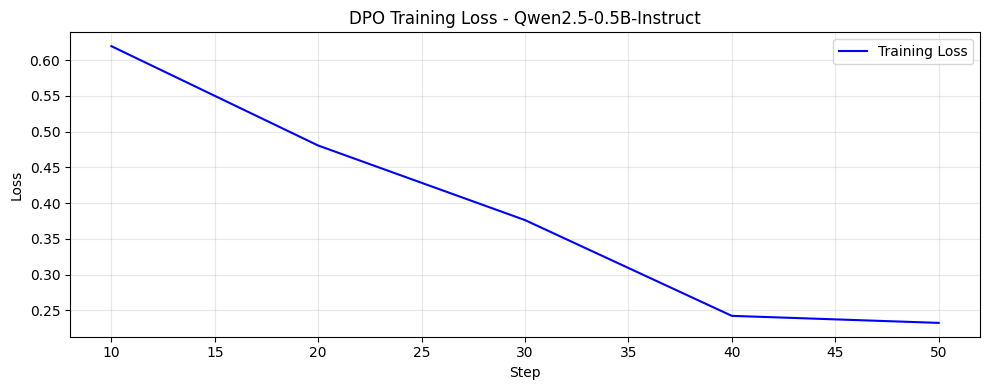

Loss inicial: 0.6194
Loss final:   0.2324


In [11]:
import matplotlib.pyplot as plt

# Extraer historial de loss del trainer
log_history = trainer.state.log_history
train_losses = [(entry['step'], entry['loss']) for entry in log_history if 'loss' in entry]

if train_losses:
    steps, losses = zip(*train_losses)
    plt.figure(figsize=(10, 4))
    plt.plot(steps, losses, color='blue', linewidth=1.5, label='Training Loss')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('DPO Training Loss - Qwen2.5-0.5B-Instruct')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Loss inicial: {losses[0]:.4f}")
    print(f"Loss final:   {losses[-1]:.4f}")
else:
    print("No hay historial de loss disponible.")